In [26]:
import matplotlib.pyplot as plt
import numpy as np

In [40]:
EPSILON = 1e-8
def savefig(
        figlist,
        log=True, 
        show_scales=True, 
        y_range:list = None, 
        figsize = (6.4, 4.8),
        label:list = None
    ):
    if (y_range == None):
        y_range = [None for _ in figlist]
    if (label == None):
        label = [None for _ in figlist]
    n = len(figlist)
    # peek into instances
    plt.figure(figsize=figsize)
    
    
    for i, f in enumerate(figlist):
        plt.subplot(n, 1, i+1)
        if (type(f) == tuple):
            for g in f:
                plt.plot(g, scalex=show_scales, scaley=show_scales)
            yrange = y_range[i] or [0, len(g)]
            plt.xlim(yrange)
        elif len(f.shape) == 1:
            plt.plot(f, scalex=show_scales, scaley=show_scales)
            yrange = y_range[i] or [0, len(f)]
            
            plt.xlim(yrange)
        elif len(f.shape) == 2:
            if log:
                x = np.log(f + EPSILON)
            else:
                x = f + EPSILON

            dim_range = y_range[i] or (0, x.shape[0], 0, x.shape[1])
            plt.imshow(x.T, origin='lower', interpolation='none', aspect='auto', extent=dim_range, cmap='magma')
            plt.title(label[i])
            
            # if i==1: plt.ylabel("frequency bin (Hz)")
            # if i==2: plt.xlabel("time frame")

        else:
            raise ValueError('Input dimension must < 3.')
        
        if (not show_scales):
            plt.yticks([])
    
    return plt
    # plt.savefig(filename)
    # plt.close()


def drawmanylines(figlist, figsize = (6.4, 4.8)):
    plt.figure(figsize=figsize)
    for i, f in enumerate(figlist):
        plt.plot(f)
    plt.xlim([0, len(f)])

def drawmanydots(figlist):
    plt.figure()
    for f in figlist:
        plt.plot(f, 'b.')
    plt.xlim([0, len(f)])
    plt.ylim([
        min(np.min(f), 0),
        np.max(f)
    ])

In [47]:
import librosa
import IPython.display

# Tale = 268
# Bat = 101
audio_path = "/home/imam/vqvae/Vu/Data/f-03-05-268.wav"
ori_sr = 48000
tgt_sr = 16000
y, sr = librosa.load(audio_path, mono=False, sr=ori_sr)
y = librosa.resample(y, orig_sr=ori_sr, target_sr=tgt_sr)[:,:16000]
ya = np.double(y[0])
yb = np.double(y[1])

IPython.display.Audio(ya, rate=tgt_sr)

<module 'matplotlib.pyplot' from '/home/imam/miniconda3/envs/preprocess/lib/python3.12/site-packages/matplotlib/pyplot.py'>

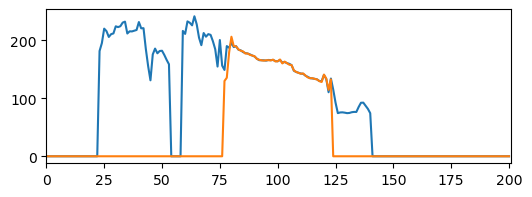

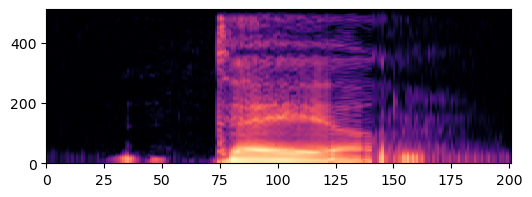

In [48]:
import pyworld as pw
from world.harvest import total_harvest

f0a, t = pw.harvest(ya, tgt_sr)
f0a = pw.stonemask(ya, f0a, t, tgt_sr)
f0b, t = pw.harvest(yb, tgt_sr)
f0b = pw.stonemask(yb, f0b, t, tgt_sr)
f0tot = total_harvest(ya, tgt_sr)['f0']

sea = pw.cheaptrick(ya, f0a, t, tgt_sr)

figsize = (6, 2)
drawmanylines([f0a, f0b], figsize=figsize)
savefig([sea], figsize=figsize)

# Checking step-by-step of Harvest

In [49]:
from world.harvest import *

x = yb
fs = tgt_sr
f0_floor: int=71
f0_ceil: int=800
frame_period: int=5

In [55]:
def viz_f0_candidate(f0_cand_list: np.ndarray):
    f0_cand_list = f0_cand_list.T
    f0_nonzero_list = []
    for f0_cand in f0_cand_list:
        f0_cand = f0_cand[f0_cand != 0.]

        if (len(f0_cand) == 0):
            f0_minmax_tuple = [0., 0.]
        else: 
            f0_minmax_tuple = [min(f0_cand), max(f0_cand)]
        f0_nonzero_list.append(f0_minmax_tuple)
    f0_nonzero_list = np.array(f0_nonzero_list)
    drawmanylines([f0_nonzero_list[:,0], f0_nonzero_list[:, 1]], (6,1))
    return f0_nonzero_list

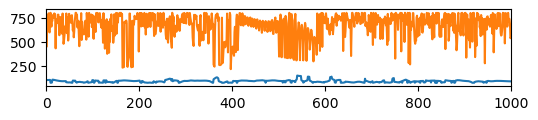

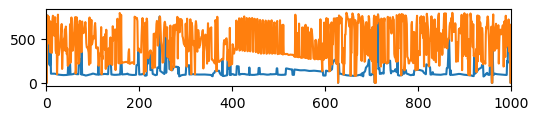

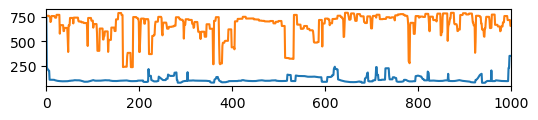

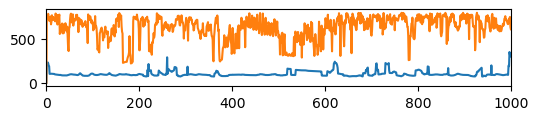

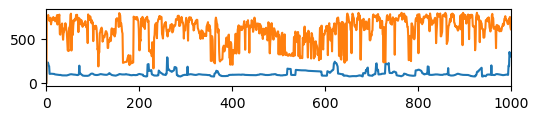

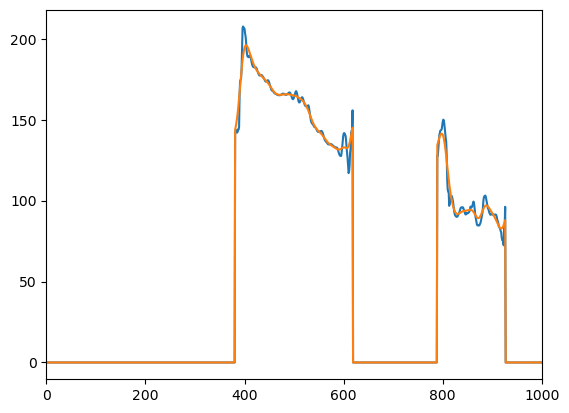

In [60]:
f0_cand_step_list = []

basic_frame_period: int = 1
target_fs = 8000
num_samples = int(1000 * len(x) / fs / basic_frame_period + 1)
basic_temporal_positions = np.arange(0, num_samples) * basic_frame_period / 1000
channels_in_octave = 40
f0_floor_adjusted = f0_floor * 0.9
f0_ceil_adjusted = f0_ceil * 1.1

boundary_f0_list = np.arange(np.ceil(np.log2(f0_ceil_adjusted / f0_floor_adjusted) * channels_in_octave)) + 1
boundary_f0_list = boundary_f0_list / channels_in_octave
boundary_f0_list = 2.0 ** boundary_f0_list
boundary_f0_list *= f0_floor_adjusted

# down - sampling to target_fs Hz
[y, actual_fs] = CalculateDownsampledSignal(x, fs, target_fs)
fft_size = int(2 ** np.ceil(np.log2(len(y) + int(fs / f0_floor_adjusted * 4 + 0.5) + 1)))
y_spectrum = np.fft.fft(y, fft_size)

raw_f0_candidates = CalculateCandidates(len(basic_temporal_positions), boundary_f0_list, len(y),
                                        basic_temporal_positions, actual_fs, y_spectrum, f0_floor, f0_ceil)
viz_f0_candidate(raw_f0_candidates)

f0_candidates, number_of_candidates = DetectCandidates(raw_f0_candidates)
viz_f0_candidate(f0_candidates)
f0_candidates = OverlapF0Candidates(f0_candidates, number_of_candidates)
viz_f0_candidate(f0_candidates)
f0_candidates, f0_candidates_score = RefineCandidates(y, actual_fs,
                                                        basic_temporal_positions, f0_candidates, f0_floor, f0_ceil)
viz_f0_candidate(f0_candidates)

f0_candidates, f0_candidates_score = RemoveUnreliableCandidates(f0_candidates, f0_candidates_score)
viz_f0_candidate(f0_candidates)

connected_f0, vuv = FixF0Contour(f0_candidates, f0_candidates_score)
smoothed_f0 = SmoothF0(connected_f0)
drawmanylines([connected_f0, smoothed_f0])
num_samples = int(1000 * len(x) / fs / frame_period + 1)
temporal_positions = np.arange(0, num_samples) * frame_period / 1000
temporal_positions_sampe = np.minimum(len(smoothed_f0) - 1, round_matlab(temporal_positions * 1000))
temporal_positions_sampe = np.array(temporal_positions_sampe, dtype=np.int32)

output =  {
    'temporal_positions': temporal_positions,
    'f0': smoothed_f0[temporal_positions_sampe],
    'vuv': vuv[temporal_positions_sampe]
}